In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

In [2]:
# Import data (Make sure to parse dates. Consider setting index column to 'date'.)
df = pd.read_csv('fcc-forum-pageviews.csv', parse_dates=[0], index_col=['date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1304 entries, 2016-05-09 to 2019-12-03
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   value   1304 non-null   int64
dtypes: int64(1)
memory usage: 20.4 KB


In [3]:
# Clean data
df = df.loc[(df['value'] >= df['value'].quantile(0.025)) & (df['value'] <= df['value'].quantile(0.975))]
df

,value
date,
2016-05-19,19736
2016-05-26,18060
2016-05-27,19997
2016-05-28,19044
2016-05-29,20325
...,...
2019-11-24,138875
2019-11-29,171584
2019-11-30,141161


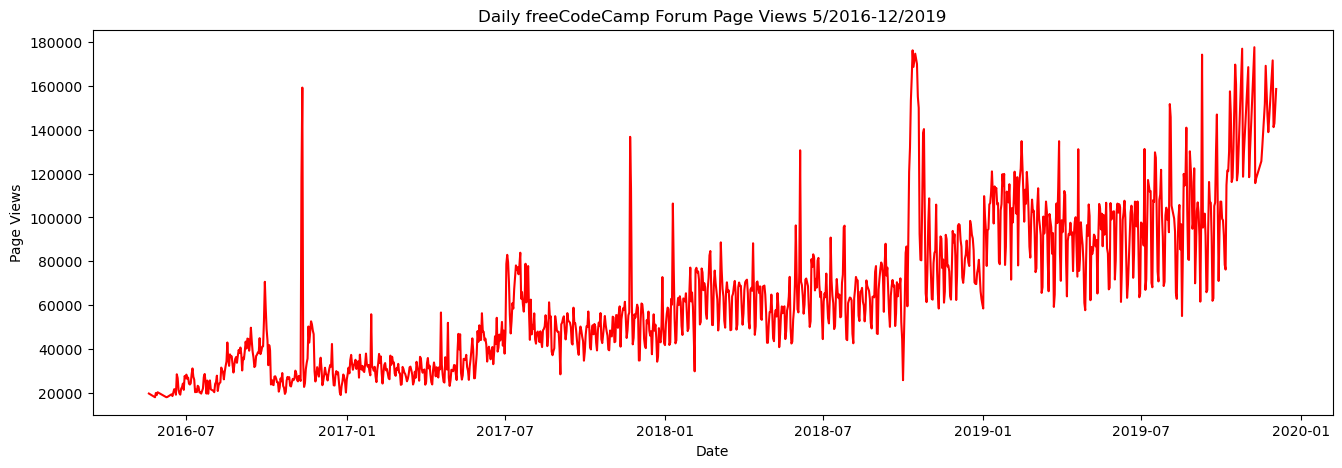

In [4]:
# def draw_line_plot():
# Draw line plot
fig, ax = plt.subplots(figsize=(16,5))
ax.plot(df.index, df['value'], color='red')
ax.set_title('Daily freeCodeCamp Forum Page Views 5/2016-12/2019')
ax.set_xlabel('Date')
ax.set_ylabel('Page Views')

# Save image and return fig (don't change this part)
fig.savefig('line_plot.png')
    # return fig

Text(0, 0.5, 'Average Page Views')

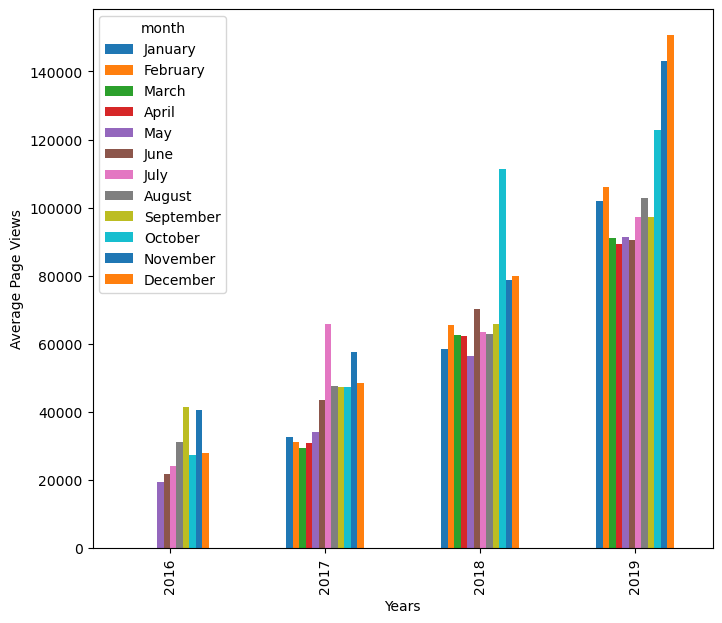

In [6]:
# def draw_bar_plot():
# Copy and modify data for monthly bar plot
df_bar = df.copy()
df_bar.reset_index(inplace=True)
df_bar['year'] = [d.year for d in df_bar.date]
df_bar['month'] = [d.strftime('%B') for d in df_bar.date]

df_bar = df_bar.groupby(['year', 'month'])['value'].mean().unstack()
df_bar = df_bar.reindex(columns=['January', 'February', 'March', 'April', 'May', 'June', 'July','August','September', 'October', 'November', 'December'])

# Draw bar plot
fig, ax = plt.subplots(figsize=(8,7))
df_bar.plot(kind='bar', ax=ax)
ax.set_xlabel('Years')
ax.set_ylabel('Average Page Views')


# Save image and return fig (don't change this part)
# fig.savefig('bar_plot.png')
    # return fig

Text(0, 0.5, 'Page Views')

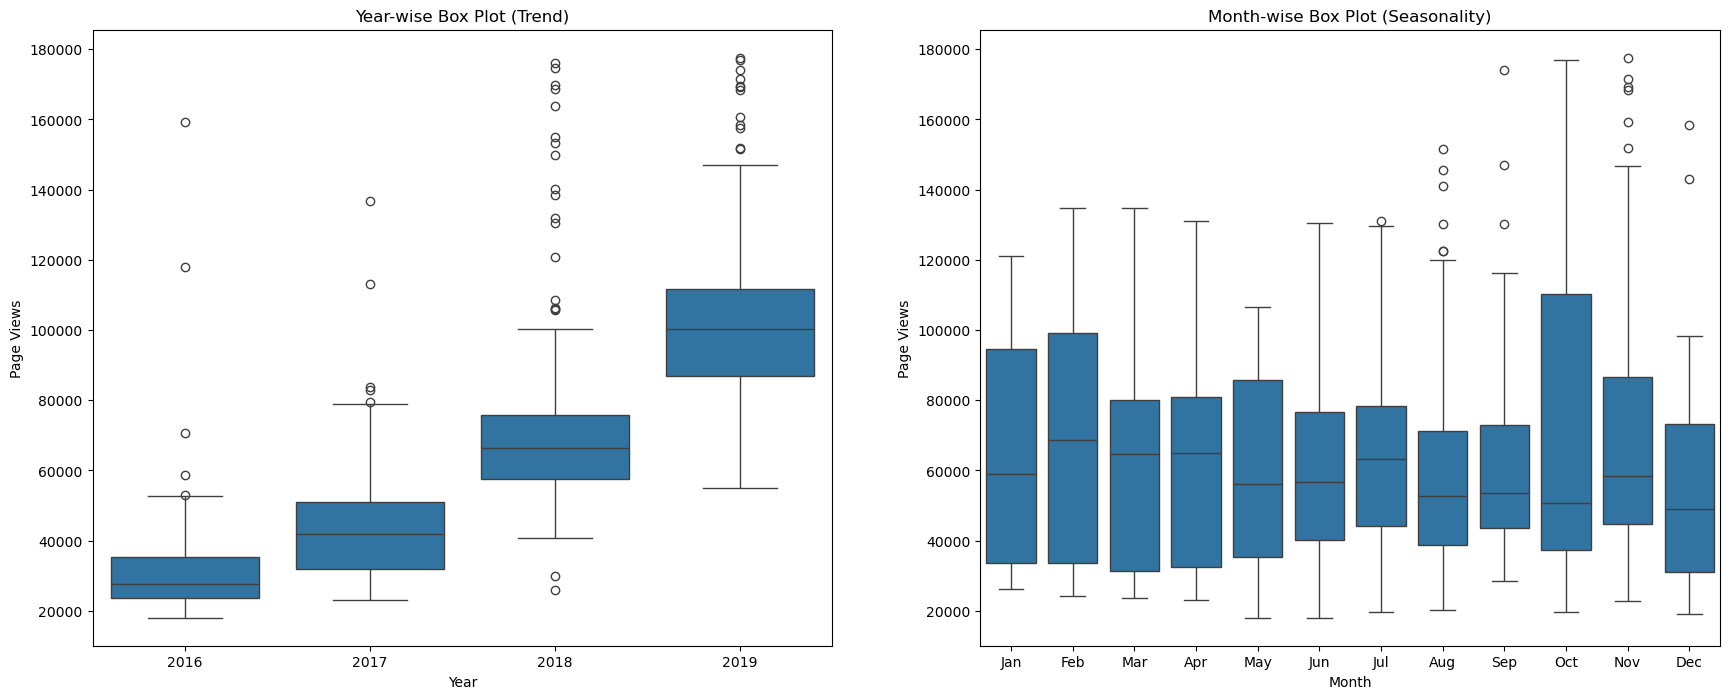

In [8]:
# def draw_box_plot():
# Prepare data for box plots (this part is done!)
df_box = df.copy()
df_box.reset_index(inplace=True)
df_box['year'] = [d.year for d in df_box.date]
df_box['month'] = [d.strftime('%b') for d in df_box.date]

# Draw box plots (using Seaborn)
df_box
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(21,8))
sns.boxplot(data=df_box, x='year', y='value', ax=ax1)
sns.boxplot(data=df_box, x='month', y='value', ax=ax2, order=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul','Aug','Sep', 'Oct', 'Nov', 'Dec'])

ax1.set_title('Year-wise Box Plot (Trend)')
ax2.set_title('Month-wise Box Plot (Seasonality)')
ax1.set_xlabel('Year')
ax2.set_xlabel('Month')
ax1.set_ylabel('Page Views')
ax2.set_ylabel('Page Views')


# Save image and return fig (don't change this part)
# fig.savefig('box_plot.png')
    # return fig